# Dax Virani | Stock Price Time Series Analysis
A notebook version of the technical analysis pipeline with synthetic OHLCV generation, trend study, volatility work, and forecasting.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from pathlib import Path

try:
    from statsmodels.tsa.seasonal import seasonal_decompose
    from statsmodels.tsa.stattools import adfuller
    from statsmodels.tsa.arima.model import ARIMA
    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor": "#0A0E1A",
    "axes.facecolor": "#111827",
    "axes.labelcolor": "#E5E7EB",
    "xtick.color": "#E5E7EB",
    "ytick.color": "#E5E7EB",
    "text.color": "#E5E7EB",
    "font.family": "DejaVu Sans"
})

DATA_PATH = Path("stock_prices.csv")
if DATA_PATH.exists():
    raw = pd.read_csv(DATA_PATH)
else:
    rng = np.random.default_rng(42)
    dates = pd.bdate_range("2019-01-01", periods=1260)
    prices = [150.0]
    vol = 0.018
    for i in range(1, len(dates)):
        vol = 0.94 * vol + 0.06 * 0.018 * abs(rng.normal())
        ret = 0.0004 + 0.0003 * np.sin(2 * np.pi * i / 252) + vol * rng.normal()
        prices.append(prices[-1] * np.exp(ret))
    prices = np.array(prices)
    raw = pd.DataFrame({
        "Date": dates,
        "Open": (prices * (1 + rng.uniform(-0.008, 0.008, len(dates)))).round(2),
        "High": (prices * rng.uniform(1.005, 1.025, len(dates))).round(2),
        "Low": (prices * rng.uniform(0.975, 0.995, len(dates))).round(2),
        "Close": prices.round(2),
        "Volume": rng.integers(500000, 5000000, len(dates))
    })
    raw.to_csv(DATA_PATH, index=False)

raw.head()

,Date,Open,High,Low,Close,Volume
0,2019-01-01,150.11,151.62,149.23,150.00,4017536
1,2019-01-02,147.68,149.43,145.35,147.39,1731229
2,2019-01-03,150.31,152.64,148.15,149.83,4476342
3,2019-01-04,147.25,147.25,144.63,146.40,2749467
4,2019-01-07,144.79,148.72,144.44,145.67,2070504


## Preprocessing and Feature Engineering
This creates return, volatility, and moving-average features before any trend study or forecast step.

In [2]:
df = raw.copy()
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.set_index("Date").sort_index().ffill().bfill()
df["Daily Return %"] = df["Close"].pct_change() * 100
df["Cumulative Return"] = (1 + df["Close"].pct_change()).cumprod()
df["MA7"] = df["Close"].rolling(7).mean()
df["MA30"] = df["Close"].rolling(30).mean()
df["MA200"] = df["Close"].rolling(200).mean()
df["Volatility30"] = df["Daily Return %"].rolling(30).std()
df["Upper_BB"] = df["MA30"] + 2 * df["Close"].rolling(30).std()
df["Lower_BB"] = df["MA30"] - 2 * df["Close"].rolling(30).std()
df["Up_Day"] = df["Daily Return %"] > 0
display(df.describe().round(2))
display(df[["Close", "Daily Return %", "Volatility30"]].tail())

,Open,High,Low,Close,Volume,Daily Return %,Cumulative Return,MA7,MA30,MA200,Volatility30,Upper_BB,Lower_BB
count,1260.00,1260.00,1260.00,1260.00,1260.00,1259.00,1259.00,1254.00,1231.00,1061.00,1230.00,1231.00,1231.00
mean,135.67,137.66,133.61,135.67,2714903.04,-0.01,0.90,135.69,135.85,137.05,1.44,143.46,128.24
std,16.35,16.64,16.16,16.37,1288994.60,1.45,0.11,16.23,15.79,12.29,0.23,16.92,15.10
min,101.51,102.82,99.66,101.92,510851.00,-4.23,0.68,102.71,104.49,111.77,0.80,108.24,98.93
25%,123.93,125.68,122.12,124.13,1647249.25,-0.96,0.83,124.76,126.52,130.45,1.32,132.84,118.79
50%,137.86,139.93,135.94,137.89,2704393.50,0.06,0.92,138.14,137.85,140.57,1.45,146.52,130.06
75%,147.40,149.38,145.20,147.24,3808647.00,0.90,0.98,147.15,146.72,145.16,1.58,154.19,139.55
max,175.77,178.86,173.96,175.70,4997831.00,4.44,1.17,174.01,171.23,156.52,1.98,181.10,164.88


,Close,Daily Return %,Volatility30
Date,,,
2023-10-24,110.98,-0.430648,1.406784
2023-10-25,113.90,2.631105,1.495878
2023-10-26,115.26,1.194030,1.497891
2023-10-27,114.39,-0.754815,1.503638
2023-10-30,116.55,1.888277,1.535079


## Trend, Seasonality, and Risk
The combined figure highlights price structure, volume behavior, return dispersion, and seasonal effects.

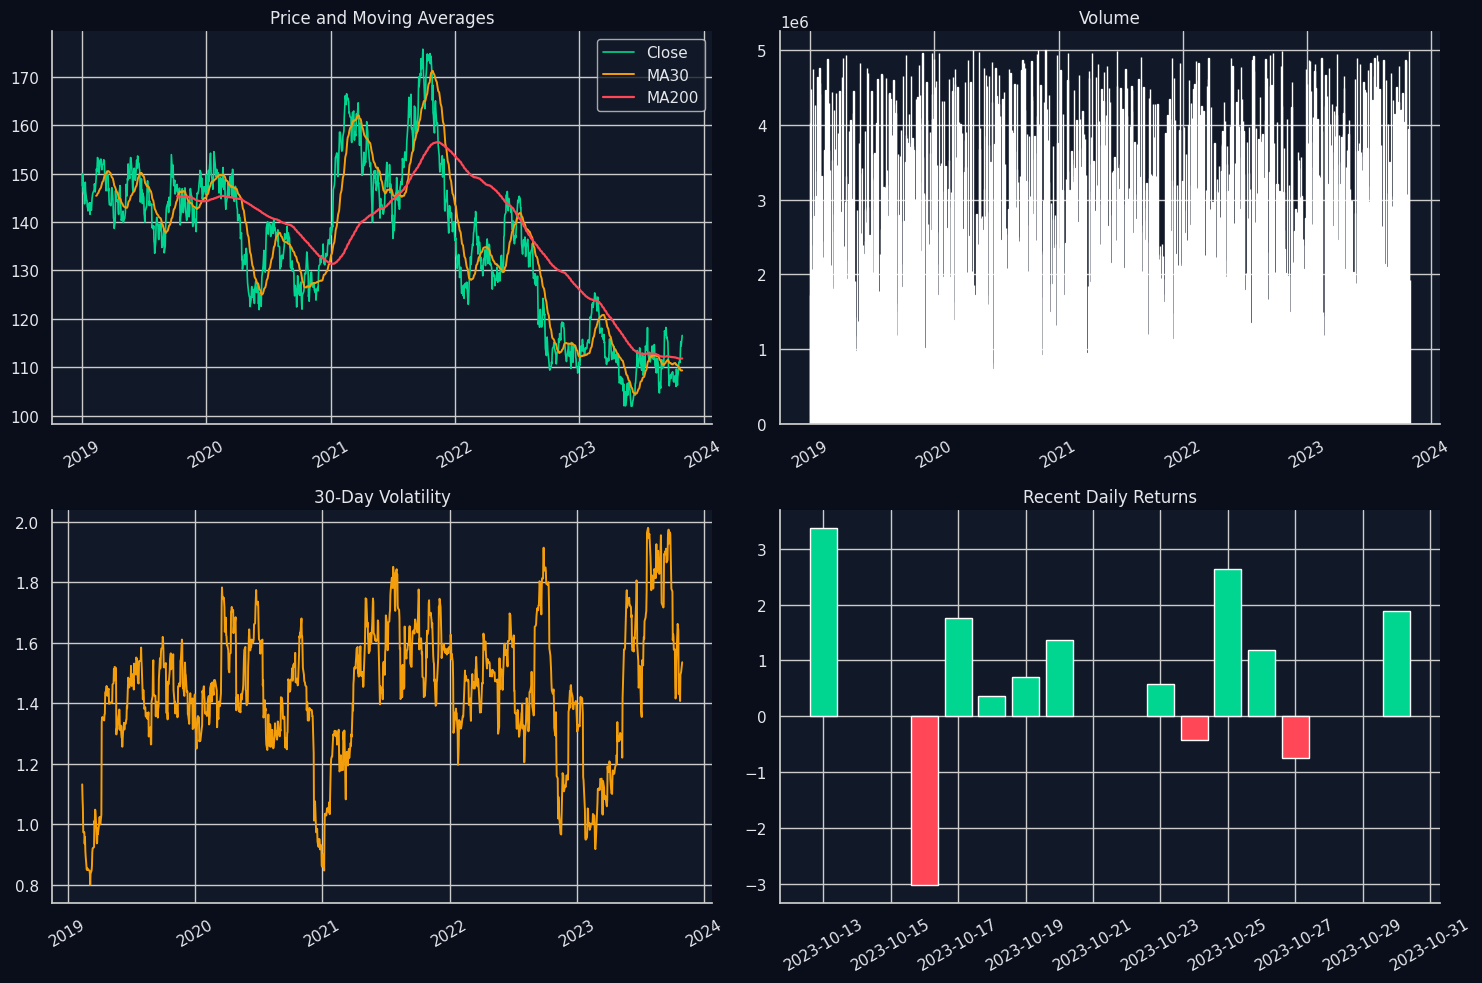

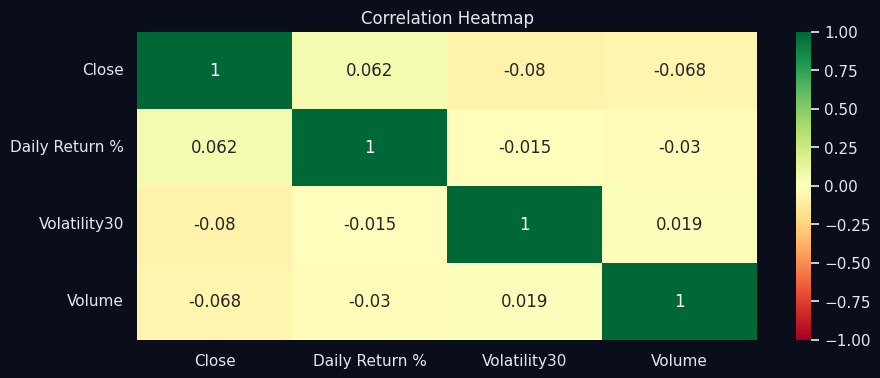

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes[0, 0].plot(df.index, df["Close"], color="#00D68F", lw=1.2, label="Close")
axes[0, 0].plot(df.index, df["MA30"], color="#F59E0B", lw=1.4, label="MA30")
axes[0, 0].plot(df.index, df["MA200"], color="#FF4757", lw=1.6, label="MA200")
axes[0, 0].set_title("Price and Moving Averages")
axes[0, 0].legend()

axes[0, 1].bar(df.index, df["Volume"], color=np.where(df["Up_Day"], "#00D68F", "#FF4757"), width=1)
axes[0, 1].set_title("Volume")

axes[1, 0].plot(df.index, df["Volatility30"], color="#F59E0B", lw=1.4)
axes[1, 0].set_title("30-Day Volatility")

axes[1, 1].bar(df.index[-12:], df["Daily Return %"].tail(12), color=np.where(df["Daily Return %"].tail(12) >= 0, "#00D68F", "#FF4757"))
axes[1, 1].set_title("Recent Daily Returns")

for ax in axes.flat:
    ax.tick_params(axis="x", rotation=30)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df[["Close", "Daily Return %", "Volatility30", "Volume"]].corr(), annot=True, cmap="RdYlGn", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Heatmap")
plt.show()

## Forecast and Diagnostics
A lightweight forecast is always available, while ARIMA and stationarity tests run only if statsmodels is installed.

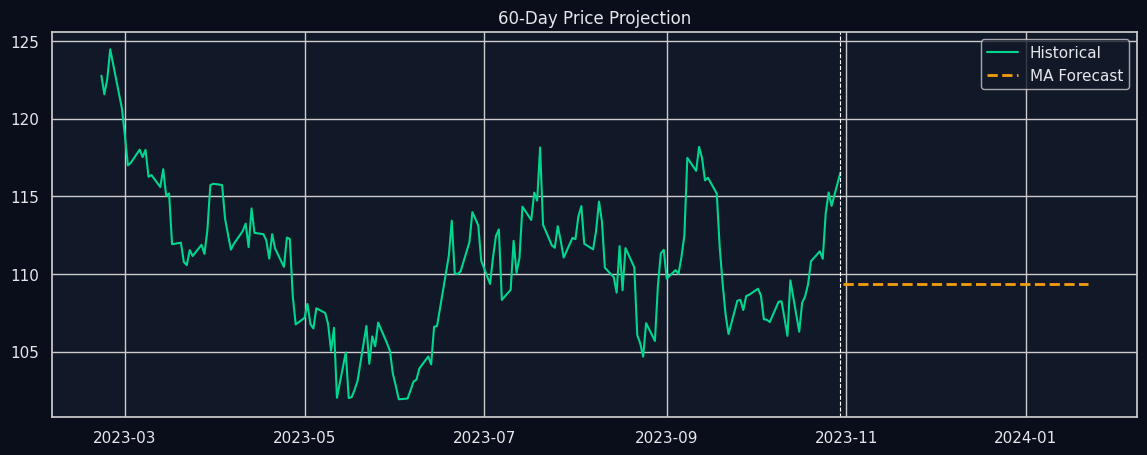

,adf_stat,p_value
0,-2.075966,0.254288


c:\Users\Dax\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Dax\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\Dax\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


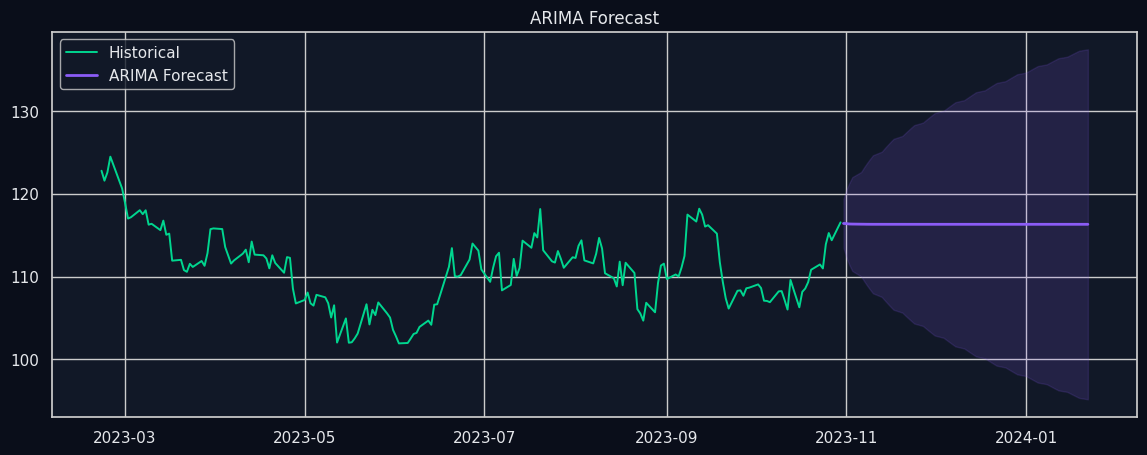

In [4]:
forecast_days = 60
forecast_dates = pd.bdate_range(df.index[-1] + pd.Timedelta(days=1), periods=forecast_days)
ma_forecast = [df["Close"].iloc[-30:].mean()] * forecast_days

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index[-180:], df["Close"].tail(180), color="#00D68F", lw=1.5, label="Historical")
ax.plot(forecast_dates, ma_forecast, color="#F59E0B", lw=2, ls="--", label="MA Forecast")
ax.axvline(df.index[-1], color="white", lw=0.8, ls="--")
ax.set_title("60-Day Price Projection")
ax.legend()
plt.show()

if HAS_STATSMODELS:
    adf = adfuller(df["Close"].dropna())
    display(pd.DataFrame({"adf_stat": [adf[0]], "p_value": [adf[1]]}))
    try:
        model = ARIMA(df["Close"].iloc[-500:], order=(2, 1, 2)).fit()
        fc = model.get_forecast(steps=forecast_days)
        pred = fc.predicted_mean
        ci = fc.conf_int(alpha=0.10)
        pred.index = forecast_dates
        ci.index = forecast_dates
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(df.index[-180:], df["Close"].tail(180), color="#00D68F", lw=1.4, label="Historical")
        ax.plot(pred.index, pred, color="#8B5CF6", lw=2, label="ARIMA Forecast")
        ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color="#8B5CF6", alpha=0.15)
        ax.set_title("ARIMA Forecast")
        ax.legend()
        plt.show()
    except Exception:
        pass